In [1]:
import torch
from torch import nn, optim

from astropy.io import fits
from astropy.wcs import WCS
from reproject import reproject_interp
from glob import glob
import matplotlib.pyplot as plt
import matplotlib.image as img
from tqdm.notebook import tqdm
import numpy as np

dirstar = '/Volumes/hdd_1/jwst_data/prod/mastDownload/JWST/**/'

Fontconfig warning: ignoring UTF-8: not a valid region tag
Matplotlib is building the font cache; this may take a moment.


In [2]:
coronagraphs = {}
wcs = {}

fnames = glob(dirstar + '*_miri_f*_i2d.fits')
# fnames = glob(dirstar + '*_cal.fits')
for fname in tqdm(fnames):
    with fits.open(fname)  as hdul:
        target = hdul[0].header['TARGNAME']
        filt = hdul[0].header['APERNAME'].split('_')[1].lower()
        if target == '* bet Pic':
            target = 'beta Pic'
        print(target, filt)
        if target not in coronagraphs:
            coronagraphs[target] = {}
            wcs[target] = WCS(hdul[1].header)
        if filt not in coronagraphs[target]:
            if len(hdul[1].data.shape) > 2:
                data, mask = reproject_interp((np.nanmedian(hdul[1].data,axis=0),hdul[1].header),wcs[target],shape_out=(250,250))
            else:
                data, mask = reproject_interp((hdul[1].data,hdul[1].header),wcs[target],shape_out=(280,280))
            coronagraphs[target][filt] = data

  0%|          | 0/55 [00:00<?, ?it/s]

HD 92209 mask1140
* alf PsA mask1550
* alf Lyr mask1550


Set DATE-AVG to '2022-07-19T06:14:09.085' from MJD-AVG.
Set DATE-END to '2022-07-19T06:18:23.146' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -37.523526 from OBSGEO-[XYZ].
Set OBSGEO-H to 1734947983.768 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2022-10-22T01:34:23.886' from MJD-AVG.
Set DATE-END to '2022-10-22T04:42:57.544' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    29.883950 from OBSGEO-[XYZ].
Set OBSGEO-H to 1292557800.610 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2023-08-19T02:43:48.441' from MJD-AVG.
Set DATE-END to '2023-08-19T03:42:16.939' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -24.770247 from OBSGEO-[XYZ].
Set OBSGEO-H to 1559173432.895 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


HR8799 mask1065
HR8799 mask1140
HR8799 mask1550


Set DATE-AVG to '2022-11-07T21:35:32.008' from MJD-AVG.
Set DATE-END to '2022-11-07T21:44:32.247' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    26.465171 from OBSGEO-[XYZ].
Set OBSGEO-H to 1451949227.784 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2022-11-08T08:40:59.841' from MJD-AVG.
Set DATE-END to '2022-11-08T08:50:00.080' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    26.274838 from OBSGEO-[XYZ].
Set OBSGEO-H to 1456491539.407 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2022-11-08T09:41:11.591' from MJD-AVG.
Set DATE-END to '2022-11-08T10:17:12.906' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    26.257490 from OBSGEO-[XYZ].
Set OBSGEO-H to 1456899646.260 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2024-02-20T19:07:12.312' from MJD-AVG.
Set DATE-END to '2024-02-20T19:50:56.329' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    19.697639 from OBSGEO-[XYZ].
Set OBSGEO-H to 1455658196.300 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


...

Set DATE-AVG to '2023-08-12T13:17:55.794' from MJD-AVG.
Set DATE-END to '2023-08-12T13:47:56.870' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -28.416806 from OBSGEO-[XYZ].
Set OBSGEO-H to 1610545251.584 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2024-08-07T05:27:55.016' from MJD-AVG.
Set DATE-END to '2024-08-07T06:07:56.490' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -28.435019 from OBSGEO-[XYZ].
Set OBSGEO-H to 1611183789.462 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2024-06-21T05:30:53.191' from MJD-AVG.
Set DATE-END to '2024-06-21T07:47:19.330' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -36.915562 from OBSGEO-[XYZ].
Set OBSGEO-H to 1746009710.270 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2023-09-04T09:49:52.389' from MJD-AVG.
Set DATE-END to '2023-09-04T12:05:43.168' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -11.944284 from OBSGEO-[XYZ].
Set OBSGEO-H to 1398055232.124 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


TWA7 mask1140
HD 181327 mask1140
HD 169142 mask1065
GJ 179 mask1550


Set DATE-AVG to '2024-08-22T09:37:56.418' from MJD-AVG.
Set DATE-END to '2024-08-22T09:57:57.095' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -19.443355 from OBSGEO-[XYZ].
Set OBSGEO-H to 1472866906.540 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-02-07T02:26:02.851' from MJD-AVG.
Set DATE-END to '2025-02-07T02:56:03.208' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    18.789527 from OBSGEO-[XYZ].
Set OBSGEO-H to 1532503492.506 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-02-20T15:26:05.807' from MJD-AVG.
Set DATE-END to '2025-02-20T16:43:29.487' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    22.177167 from OBSGEO-[XYZ].
Set OBSGEO-H to 1389751369.943 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-11-16T18:02:06.790' from MJD-AVG.
Set DATE-END to '2025-11-16T18:17:06.908' from MJD-END'. [astropy.wcs.wcs]


Gaia DR3 5877725249280411392 mask1550
Gaia DR3 5877725249280411392 mask1550
HIP 108706 mask1065
HIP 108706 mask1550
Gaia DR3 5877725146201190144 mask1550
Gaia DR3 5877725146201190144 mask1550


Set OBSGEO-B to    16.097788 from OBSGEO-[XYZ].
Set OBSGEO-H to 1645952821.966 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-11-16T17:10:19.721' from MJD-AVG.
Set DATE-END to '2025-11-16T17:25:19.839' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    16.108016 from OBSGEO-[XYZ].
Set OBSGEO-H to 1645839295.037 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2025-04-25T15:37:27.674' from MJD-AVG.
Set DATE-END to '2025-04-25T16:54:51.354' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -19.446673 from OBSGEO-[XYZ].
Set OBSGEO-H to 1513449672.293 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


/var/folders/bw/by_tzbnn35zdxq0_rkj1kl61gjgsbb/T/ipykernel_4300/380857766.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


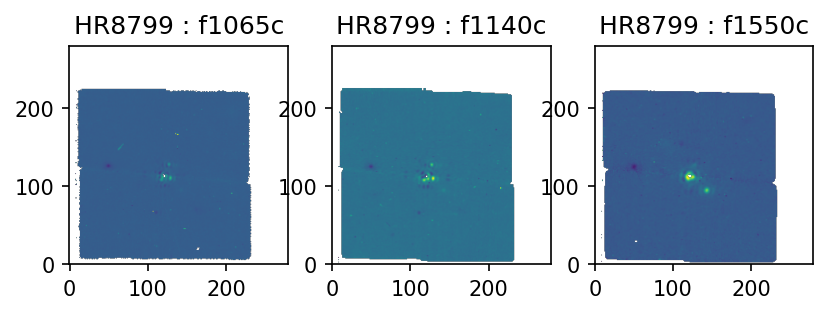

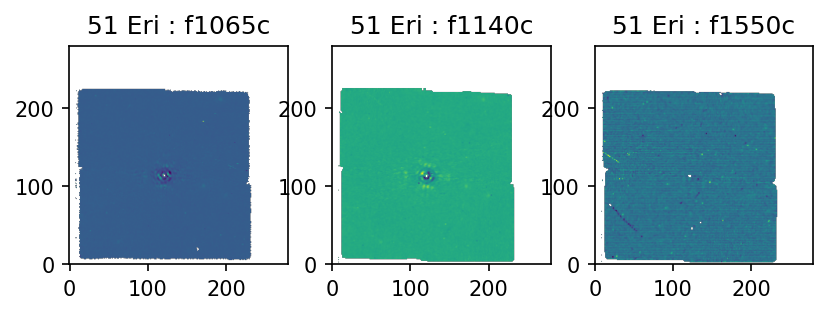

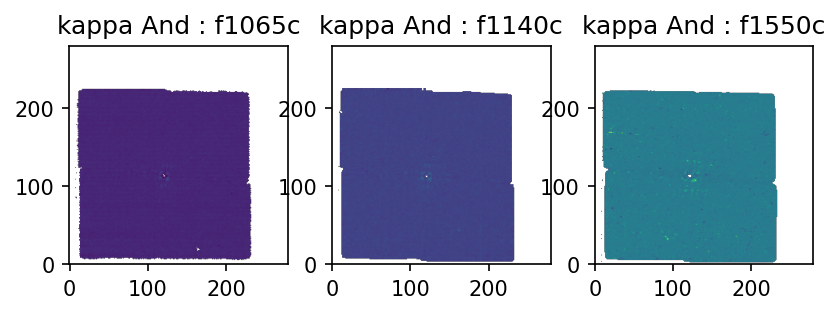

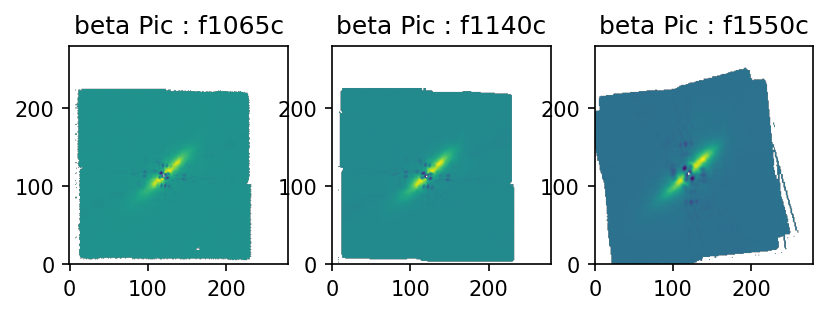

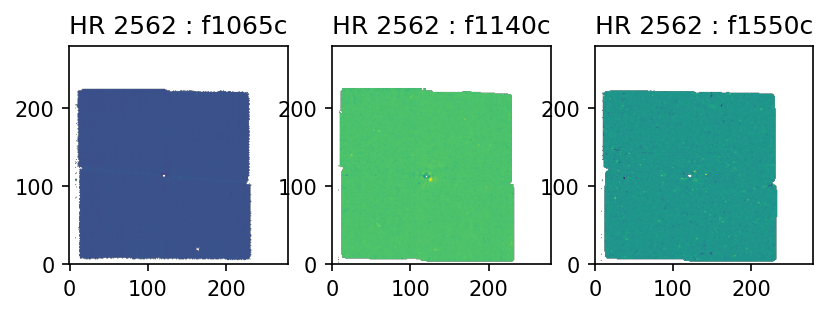

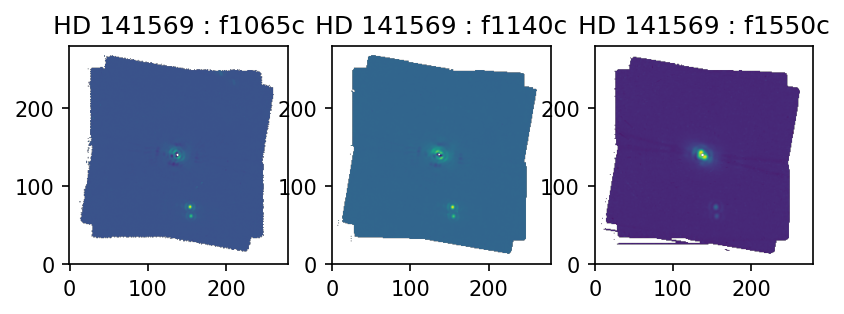

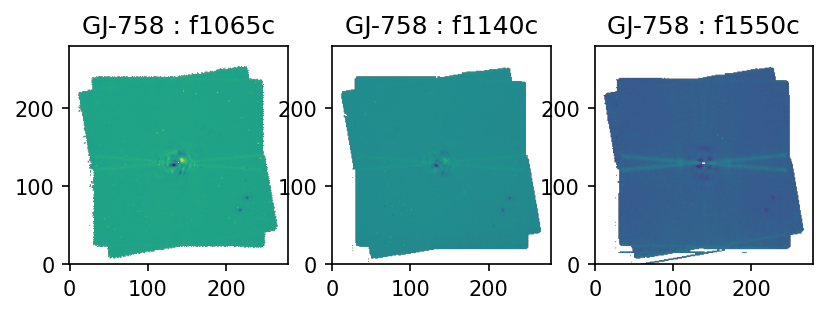

In [3]:
keys = set(coronagraphs.keys())
for target in keys:
    if len(coronagraphs[target]) < 3:
        coronagraphs.pop(target)
# bad data
# observations.pop((np.float64(236.69),np.float64(-6.12)))

for target in coronagraphs:
    fig, axs = plt.subplots(1,3)
    if 'mask1065' in coronagraphs[target]:
        axs[0].imshow(coronagraphs[target]['mask1065'], origin='lower')
        axs[0].set_title(f'{target} : f1065c')
    if 'mask1140' in coronagraphs[target]:
        axs[1].imshow(coronagraphs[target]['mask1140'], origin='lower')
        axs[1].set_title(f'{target} : f1140c')
    if 'mask1550' in coronagraphs[target]:
        axs[2].imshow(coronagraphs[target]['mask1550'], origin='lower')
        axs[2].set_title(f'{target} : f1550c')
    fig.set_dpi(150)
    fig.show()

In [4]:
ifus = {}
fnames = glob(dirstar + '*_miri_*_x1d.fits')
for fname in tqdm(fnames):
    with fits.open(fname)  as hdul:
        target = hdul[0].header['TARGNAME']
        if target not in ifus:
            ifus[target] = {}
        data = np.zeros((len(hdul[1].data),len(hdul[1].data[0])))
        for row in range(len(hdul[1].data)):
            data[row,:] = hdul[1].data[row]
        ifus[target][fname.split('_miri_')[-1].split('_')[0]] = data

  0%|          | 0/12 [00:00<?, ?it/s]

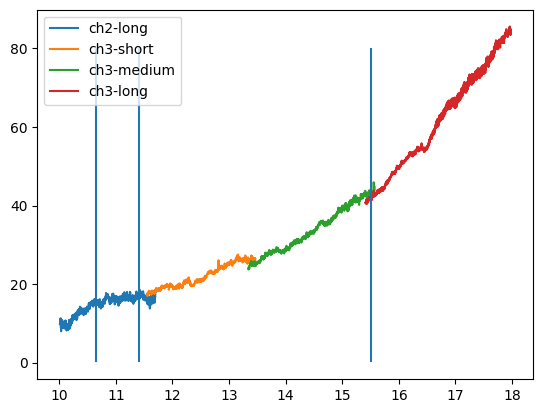

In [5]:
for filt in ['ch2-long','ch3-short','ch3-medium','ch3-long']:
    plt.plot(ifus['* bet Pic'][filt][:,0],ifus['* bet Pic'][filt][:,6],label=filt)
plt.legend()
plt.vlines([10.65,11.4,15.5],0.01, 80)
plt.show()

star_1550 = ifus['* bet Pic']['ch3-medium'][np.argmin(np.abs(ifus['* bet Pic']['ch3-medium'][:,0] - 15.5)),6]
data_1550 = np.divide(np.abs(coronagraphs['beta Pic']['mask1550']),np.nanmax(np.abs(coronagraphs['beta Pic']['mask1550'].ravel())))*star_1550
star_1140 = ifus['* bet Pic']['ch2-long'][np.argmin(np.abs(ifus['* bet Pic']['ch2-long'][:,0] - 11.4)),6]
data_1140 = np.divide(np.abs(coronagraphs['beta Pic']['mask1140']),np.nanmax(np.abs(coronagraphs['beta Pic']['mask1140'].ravel())))*star_1140
star_1065 = ifus['* bet Pic']['ch2-long'][np.argmin(np.abs(ifus['* bet Pic']['ch2-long'][:,0] - 10.65)),6]
data_1065 = np.divide(np.abs(coronagraphs['beta Pic']['mask1065']),np.nanmax(np.abs(coronagraphs['beta Pic']['mask1065'].ravel())))*star_1065

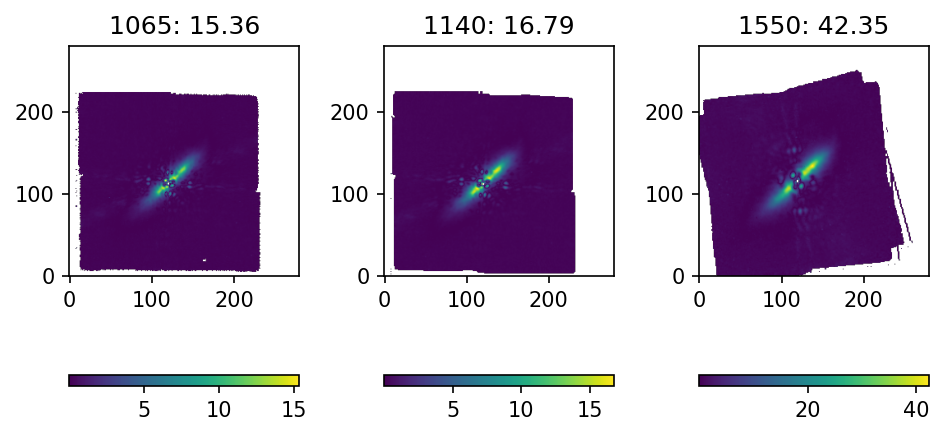

In [6]:
fig, axs = plt.subplots(1,3)
caxs = [0,0,0]

caxs[0] = axs[0].imshow(data_1065,origin='lower')
axs[0].set_title(f'1065: {star_1065:.2f}')

caxs[1] = axs[1].imshow(data_1140,origin='lower')
axs[1].set_title(f'1140: {star_1140:.2f}')

caxs[2] = axs[2].imshow(data_1550,origin='lower')
axs[2].set_title(f'1550: {star_1550:.2f}')

for j in range(3):
    plt.colorbar(caxs[j],ax=axs[j],fraction=0.05,location='bottom')

fig.set_dpi(150)
plt.tight_layout()
plt.show()

In [ ]:
with fits.open(fnames[0])  as hdul:
    print(hdul[0].header['FILTER'])

In [ ]:
hdul[0].header